# 01 — 传感器数据探索

## 目标
- 了解加速度计、陀螺仪、麦克风数据的格式和特征
- 加载并可视化原始传感器数据
- 建立数据预处理基线

## 传感器说明
| 传感器 | 采样率 | 维度 | 用途 |
|--------|--------|------|------|
| 加速度计 | 20-50 Hz | X, Y, Z (m/s²) | 轮胎偏摆检测 |
| 陀螺仪 | 20-50 Hz | X, Y, Z (rad/s) | 车头不正检测 |
| 麦克风 | 44100 Hz | 单声道 | 链条异响检测 |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
%matplotlib inline

### 加载并可视化加速度计数据

C:\Users\Sherlock\AppData\Local\Temp\ipykernel_22076\1611815119.py:24: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Sherlock\AppData\Local\Temp\ipykernel_22076\1611815119.py:24: UserWarning: Glyph 36895 (\N{CJK UNIFIED IDEOGRAPH-901F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Sherlock\AppData\Local\Temp\ipykernel_22076\1611815119.py:24: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Sherlock\AppData\Local\Temp\ipykernel_22076\1611815119.py:24: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Sherlock\AppData\Local\Temp\ipykernel_22076\1611815119.py:24: UserWarning: Glyph 24120 (\N{CJK UNIFIED IDEOGRAPH-5E38}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Sherlock\AppData\Local\Temp\ipykernel_22076\1611815119.py:24: UserWarning: Glyph 39569 (\N{CJK UNIFIE

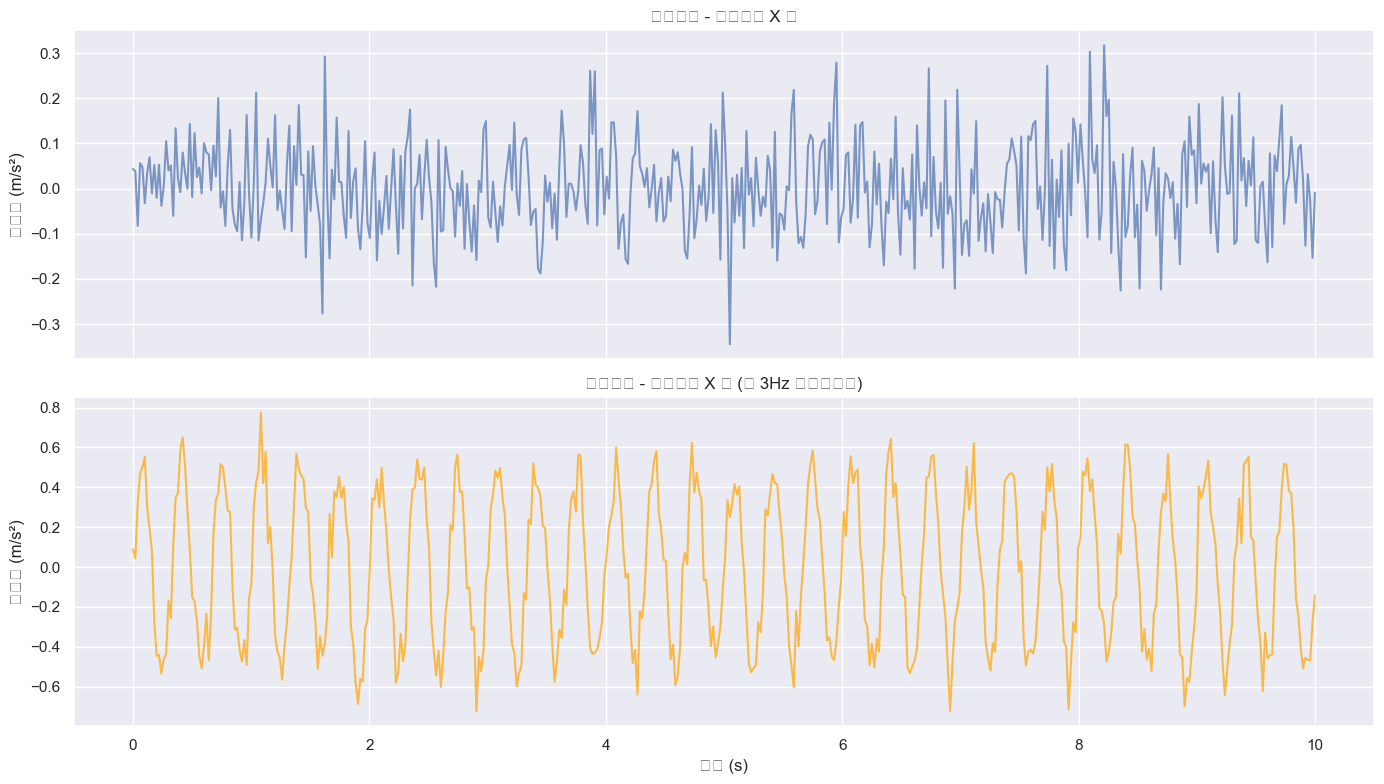

In [2]:
# TODO: Load real accelerometer data from ml/data/raw/
# For now, generate synthetic data to demonstrate the pipeline

sample_rate = 50  # Hz
duration = 10     # seconds
t = np.linspace(0, duration, sample_rate * duration)

# Simulate normal riding vibration (low amplitude random)
normal_x = 0.1 * np.random.randn(len(t))

# Simulate wheel wobble (3 Hz periodic + noise)
wobble_x = 0.5 * np.sin(2 * np.pi * 3 * t) + 0.1 * np.random.randn(len(t))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(t, normal_x, alpha=0.7)
axes[0].set_title("正常骑行 - 加速度计 X 轴")
axes[0].set_ylabel("加速度 (m/s²)")

axes[1].plot(t, wobble_x, color="orange", alpha=0.7)
axes[1].set_title("轮胎偏摆 - 加速度计 X 轴 (含 3Hz 周期性振动)")
axes[1].set_xlabel("时间 (s)")
axes[1].set_ylabel("加速度 (m/s²)")

plt.tight_layout()
plt.show()

### 频谱分析 (FFT)

C:\Users\Sherlock\AppData\Local\Temp\ipykernel_22076\324755484.py:21: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Sherlock\AppData\Local\Temp\ipykernel_22076\324755484.py:21: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Sherlock\AppData\Local\Temp\ipykernel_22076\324755484.py:21: UserWarning: Glyph 24133 (\N{CJK UNIFIED IDEOGRAPH-5E45}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Sherlock\AppData\Local\Temp\ipykernel_22076\324755484.py:21: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Sherlock\AppData\Local\Temp\ipykernel_22076\324755484.py:21: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Sherlock\AppData\Local\Temp\ipykernel_22076\324755484.py:21: UserWarning: Glyph 24120 (\N{CJK UNIFIED IDEO

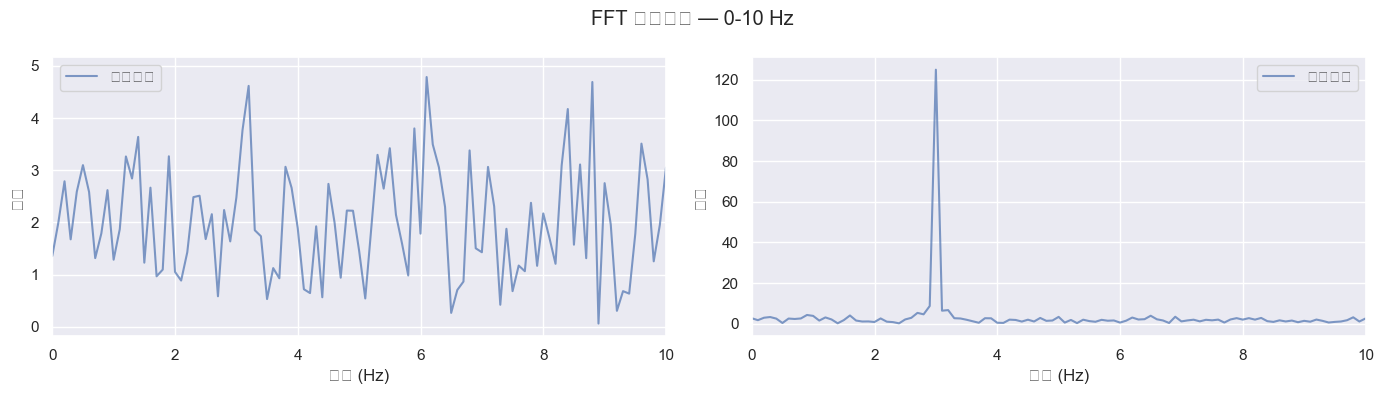

In [3]:
from scipy import fft

def plot_spectrum(signal, sr, label="", ax=None):
    n = len(signal)
    freqs = fft.rfftfreq(n, 1/sr)
    magnitude = np.abs(fft.rfft(signal))
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(freqs, magnitude, alpha=0.7, label=label)
    ax.set_xlabel("频率 (Hz)")
    ax.set_ylabel("幅值")
    ax.set_xlim(0, 10)  # Focus on 0-10 Hz
    if label:
        ax.legend()
    return ax

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_spectrum(normal_x, sample_rate, "正常骑行", ax=axes[0])
plot_spectrum(wobble_x, sample_rate, "轮胎偏摆", ax=axes[1])
plt.suptitle("FFT 频谱对比 — 0-10 Hz")
plt.tight_layout()
plt.show()